In [1]:
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt

# 1. تحميل البيانات
df = pd.read_csv("monthly_revenue.csv")

# 2. Prophet بيتطلب أسماء أعمدة محددة بالظبط: ds (التاريخ) و y (القيمة المراد توقعها)
df['ds'] = pd.to_datetime(df['OrderMonth'], format='%Y-%m')
df['y'] = df['MonthlyRevenue']

df_prophet = df[['ds', 'y']]
print(df_prophet)

           ds          y
0  2017-01-01  111798.36
1  2017-02-01  234223.40
2  2017-03-01  359198.85
3  2017-04-01  340669.68
4  2017-05-01  489338.25
5  2017-06-01  421923.37
6  2017-07-01  481604.52
7  2017-08-01  554699.70
8  2017-09-01  607399.67
9  2017-10-01  648247.65
10 2017-11-01  987765.37
11 2017-12-01  726033.19
12 2018-01-01  924645.00
13 2018-02-01  826437.13
14 2018-03-01  953356.25
15 2018-04-01  973534.09
16 2018-05-01  977544.69
17 2018-06-01  856077.86
18 2018-07-01  867953.46
19 2018-08-01  838576.64


In [2]:
# 1. إنشاء وتدريب الموديل
model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
model.fit(df_prophet)

# 2. إنشاء إطار زمني مستقبلي (6 أشهر قادمة بعد آخر بيانات عندنا)
future = model.make_future_dataframe(periods=6, freq='MS')  # MS = Month Start

# 3. التوقع
forecast = model.predict(future)

# 4. عرض آخر 10 صفوف (فيها آخر بيانات حقيقية + كل الشهور المتوقعة)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(10)

Yearly seasonality is enabled with less than 730 days (approximately 2 years) of history. The model may be under-identified, and the trend/seasonality decomposition can be unstable and dependent on the Prophet/Stan version. Consider disabling yearly seasonality or providing more history.
23:48:03 - cmdstanpy - INFO - Chain [1] start processing
23:48:21 - cmdstanpy - INFO - Chain [1] done processing


,ds,yhat,yhat_lower,yhat_upper
16,2018-05-01,9.775446e+05,9.775446e+05,9.775446e+05
17,2018-06-01,8.560779e+05,8.560779e+05,8.560779e+05
18,2018-07-01,8.679534e+05,8.679534e+05,8.679534e+05
19,2018-08-01,8.385767e+05,8.385767e+05,8.385767e+05
20,2018-09-01,1.775933e+06,1.768769e+06,1.783054e+06
21,2018-10-01,7.269309e+05,7.027883e+05,7.493933e+05
22,2018-11-01,1.645114e+06,1.598904e+06,1.690195e+06
23,2018-12-01,4.867564e+05,4.166543e+05,5.566342e+05
24,2019-01-01,1.574206e+06,1.475264e+06,1.675189e+06
25,2019-02-01,1.188149e+06,1.055666e+06,1.324130e+06


In [3]:
# إعادة بناء الموديل بدون افتراض موسمية سنوية (البيانات غير كافية لإثباتها بثقة)
model = Prophet(yearly_seasonality=False, weekly_seasonality=False, daily_seasonality=False)
model.fit(df_prophet)

future = model.make_future_dataframe(periods=6, freq='MS')
forecast = model.predict(future)

forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(10)

23:54:51 - cmdstanpy - INFO - Chain [1] start processing
23:54:51 - cmdstanpy - INFO - Chain [1] done processing


,ds,yhat,yhat_lower,yhat_upper
16,2018-05-01,9.280611e+05,7.856504e+05,1.079210e+06
17,2018-06-01,9.704770e+05,8.244150e+05,1.122146e+06
18,2018-07-01,1.011525e+06,8.663838e+05,1.156150e+06
19,2018-08-01,1.053941e+06,9.143572e+05,1.197146e+06
20,2018-09-01,1.096356e+06,9.523881e+05,1.235161e+06
21,2018-10-01,1.137404e+06,9.941012e+05,1.280666e+06
22,2018-11-01,1.179820e+06,1.033995e+06,1.327636e+06
23,2018-12-01,1.220868e+06,1.073860e+06,1.369739e+06
24,2019-01-01,1.263284e+06,1.112444e+06,1.395387e+06
25,2019-02-01,1.305700e+06,1.158794e+06,1.459336e+06


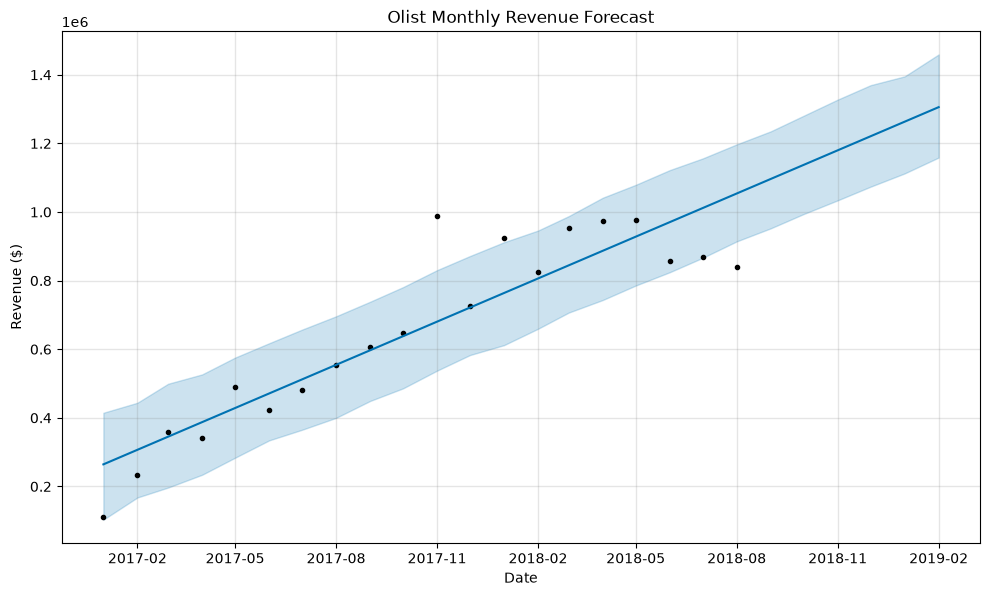

In [4]:
fig1 = model.plot(forecast)
plt.title("Olist Monthly Revenue Forecast")
plt.xlabel("Date")
plt.ylabel("Revenue ($)")
plt.show()

In [5]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

# مقارنة القيم الفعلية بالقيم اللي الموديل "توقعها" لنفس الفترة التاريخية
actual = df_prophet['y'].values
predicted = forecast['yhat'][:len(df_prophet)].values

mae = mean_absolute_error(actual, predicted)
mape = mean_absolute_percentage_error(actual, predicted) * 100

print(f"Mean Absolute Error (MAE): ${mae:,.2f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

Mean Absolute Error (MAE): $82,919.96
Mean Absolute Percentage Error (MAPE): 17.57%


In [6]:
import sqlite3

conn = sqlite3.connect("olist_forecast.db")

# تصدير جدول التوقع الكامل (القيم التاريخية + المستقبلية)
forecast_export = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
forecast_export['ds'] = forecast_export['ds'].dt.strftime('%Y-%m')
forecast_export.to_sql('sales_forecast', conn, if_exists='replace', index=False)

print(f"✅ تم تصدير {len(forecast_export)} صف إلى جدول sales_forecast")
conn.close()

✅ تم تصدير 26 صف إلى جدول sales_forecast
